In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [ ]:
pd.options.mode.chained_assignment = None 

all_cases_best_results = {}
cases = ['0', '01', '03', '1']  # Case identifiers corresponding to different noise levels, 0 = noiseless, 1 = 1std noise

for case_id in cases:
    all_runs_best_results_list = []
    
    for run_num in range(11):
        try:
            history_df = pd.read_csv(f"../sweep_results/metrics_log/loss_history_df_{case_id}_{run_num}.csv")  # Training history with validation and test losses, and parameter error
            re_eval_df = pd.read_csv(f"../sweep_results/metrics_log/re_eval_results_df_{case_id}_{run_num}.csv")  # Re-evaluation results with test MSE for the best model at each data size
            
        except FileNotFoundError:
            print(f"Warning: CSV files for case '{case_id}', run {run_num} not found. Skipping run.")
            continue
            
        combined_df = pd.merge(history_df, re_eval_df, on=['data_size', 'epoch'], how='left')

        best_results = []
        # Over tested data sizes
        for size in [5,10,20,40,60]:
            size_df = combined_df[combined_df['data_size'] == size].copy()
            
            if size_df.empty:
                continue

            # Find the row corresponding to the best model (minimum validation loss)
            best_epoch_row = size_df.loc[size_df['val_loss'].idxmin()]
            
            # Get the re-evaluated MSE from the closest available epoch (since we didn't re-evaluate every epoch)
            re_eval_subset = size_df.dropna(subset=['re_eval_test_mse'])
            if not re_eval_subset.empty:
                closest_re_eval_row = re_eval_subset.iloc[(re_eval_subset['epoch'] - best_epoch_row['epoch']).abs().argsort()[:1]]
                re_eval_mse = closest_re_eval_row['re_eval_test_mse']
            else:
                re_eval_mse = np.nan

            best_results.append({
                'data_size': size,
                'best_val_loss': best_epoch_row['val_loss'],
                'test_loss_at_best': best_epoch_row['test_lX'], # Only care about data loss at best epoch
                'param_error_at_best': best_epoch_row['param_error_rmsre'],
                're_eval_mse_at_best': re_eval_mse,
                'best_epoch': best_epoch_row['epoch']
            })
        
        if best_results:
            all_runs_best_results_list.append(pd.DataFrame(best_results))
        else:
            print(f"Warning: No best results found for case '{case_id}', run {run_num}.")

    all_runs_df = pd.concat(all_runs_best_results_list)
    
    mean_results = all_runs_df.groupby('data_size').mean()
    sem_results = all_runs_df.groupby('data_size').sem()
    
    all_cases_best_results[case_id] = {'mean': mean_results, 'sem': sem_results}

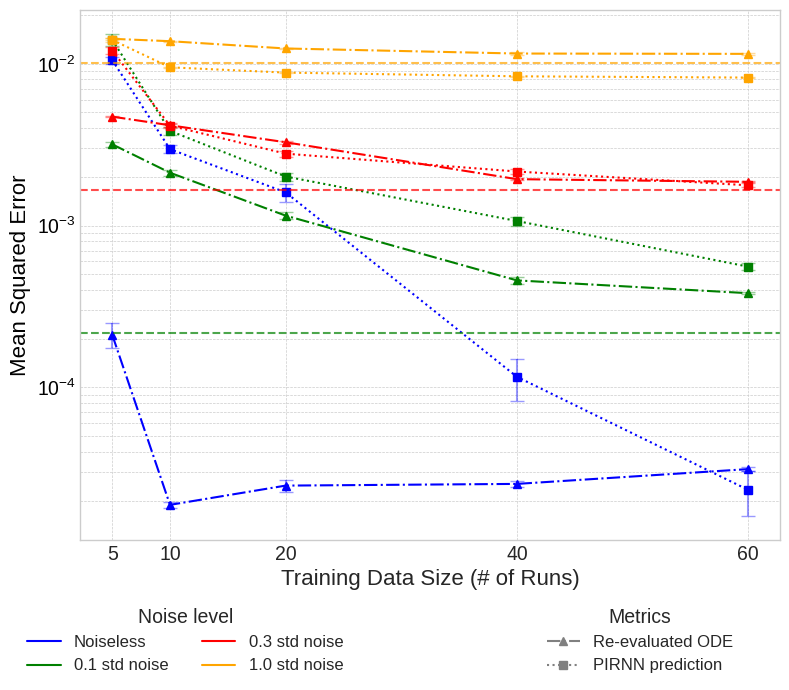

In [ ]:
# y_scale is obtained from data generation step
y_scale = {'0':np.array([3.38087406e+05, 2.45658822e+03, 2.57740255e+01, 3.65173638e-01, 4.97344188e-01]),
           '01':np.array([3.50253710e+05, 2.54929415e+03, 2.66138691e+01, 3.85584836e-01, 5.03993957e-01]),
           '03':np.array([3.74586365e+05, 2.73470924e+03, 2.86000320e+01, 4.39899155e-01, 5.32132101e-01]),
           '1':np.array([5.38736925e+05, 3.37932692e+03, 3.85115124e+01, 6.12347669e-01, 6.47480645e-01])}

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(8,7), tight_layout = True)

colors = {'0': 'blue', '01': 'green', '03': 'red', '1': 'orange'}
case_labels = {'0': 'Noiseless', '01': '0.1 std noise', '03': '0.3 std noise', '1': '1.0 std noise'}

styles = {
    're_eval_mse_at_best': {'linestyle': '-.', 'marker': '^', 'label': 'Re-evaluated ODE'},
    'test_loss_at_best': {'linestyle': ':', 'marker': 's', 'label': 'PIRNN prediction'},
}

case_baseline = {'01': 0.00021602078615121968, '03': 0.0016517706913698196, '1': 0.010120400843672776}  # Baseline MSE values for each noise level obtained from data generation step

for case_id, results_data in all_cases_best_results.items():
    mean_df = results_data['mean']
    sem_df = results_data['sem']
    color = colors.get(case_id, 'black')
    x_values = mean_df.index

    metric_mean = mean_df['re_eval_mse_at_best']
    metric_sem = sem_df['re_eval_mse_at_best']
    
    # Plot the mean line
    ax1.plot(x_values, metric_mean, color=color, **styles['re_eval_mse_at_best'])
    
    # Plot error bar
    ax1.errorbar(x_values, metric_mean, yerr=metric_sem,
                 color=color, linestyle='none', marker='', 
                 capsize=5, alpha=0.4, elinewidth=1.5)

    # --- Plot test_loss_at_best (Mean and Error Bar) ---
    metric_mean = mean_df['test_loss_at_best']
    metric_sem = sem_df['test_loss_at_best']

    # Plot the mean line
    ax1.plot(x_values, metric_mean, color=color, **styles['test_loss_at_best'])

    # Plot the error bar
    ax1.errorbar(x_values, metric_mean, yerr=metric_sem,
                 color=color, linestyle='none', marker='', 
                 capsize=5, alpha=0.4, elinewidth=1.5)
    try:
        ax1.axhline(y = case_baseline[case_id], linestyle='--', color = color, alpha = 0.7)
    except:
        continue

ax1.set_xlabel('Training Data Size (# of Runs)', fontsize=16)
ax1.set_ylabel('Mean Squared Error', fontsize=16, color='black')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks([5, 10, 20, 40, 60])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

case_patches = [mlines.Line2D([], [], color=colors[case], label=case_labels[case]) for case in cases if case in all_cases_best_results]
style_patches = [mlines.Line2D([], [], color='gray', **style) for style in styles.values()]

legend1 = plt.legend(handles=case_patches, title='Noise level', loc='upper center', bbox_to_anchor=(0.15, -0.1), ncol=2, fontsize=12, title_fontsize = 14)
plt.legend(handles=style_patches, title='Metrics', loc='upper center', bbox_to_anchor=(0.8, -0.1), ncol=1, fontsize=12, title_fontsize = 14)
plt.gca().add_artist(legend1)

# plt.savefig("./model_performance_avg.svg")
# plt.savefig("./model_performance_avg.png")
# plt.savefig("./model_performance_avg.pdf")